**Binary Classification**

In this folder the goal is to make binary classification for next day.

In this file we will use the sentiments of older pipeline that preprocessed the news data.

The architecture of the pipeline is suspicious that can cause loss of information.

If the classification results are bad new pipeline will be builded. 

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
path = '../last-1/datasets/mega_dataset.csv'
df = pd.read_csv(path, parse_dates=['Date'])
df.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,SLV,^GSPC,sent_enc,increase_ind
0,2023-01-03,0.279186,0.614588,0.722545,0.810606,0.351997,0.528008,0.411833,2,0
1,2023-01-04,0.292612,0.614588,0.722545,0.810606,0.374767,0.520214,0.419316,2,1
2,2023-01-05,0.274683,0.614588,0.722545,0.810606,0.338186,0.495860,0.407670,2,-1
3,2023-01-06,0.301284,0.614588,0.722545,0.810606,0.374393,0.521676,0.430246,2,1
4,2023-01-09,0.304536,0.614588,0.722545,0.810606,0.426652,0.512908,0.429469,0,1


In [17]:
df.columns

Index(['Date', 'Gold_Price', 'Crude_Oil', 'Inflation', 'Interest_Rate',
       'USD_EUR', 'SLV', '^GSPC', 'sent_enc', 'increase_ind'],
      dtype='object')

In [18]:
drop = ['Crude_Oil', 'Inflation', 'Interest_Rate',
       'USD_EUR', 'SLV', '^GSPC']

df = df.drop(columns=drop)
df.head()

,Date,Gold_Price,sent_enc,increase_ind
0,2023-01-03,0.279186,2,0
1,2023-01-04,0.292612,2,1
2,2023-01-05,0.274683,2,-1
3,2023-01-06,0.301284,2,1
4,2023-01-09,0.304536,0,1


In [19]:
df['sent_enc'].value_counts()

sent_enc
2    263
1    126
0    112
Name: count, dtype: int64

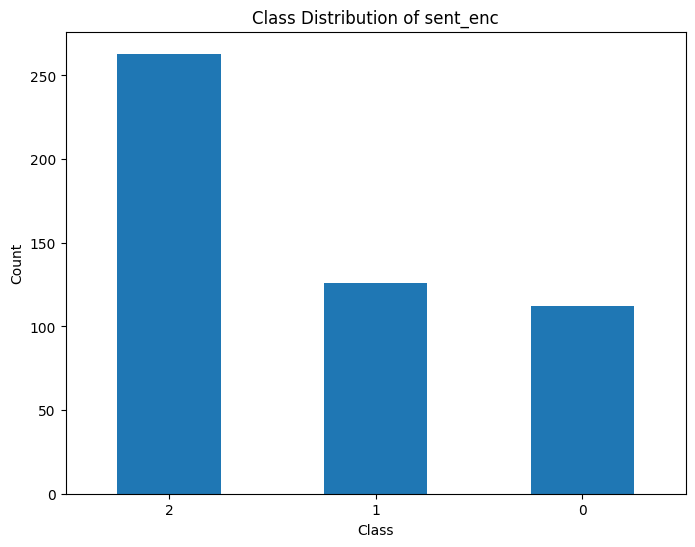

In [20]:
class_counts = df['sent_enc'].value_counts()


plt.figure(figsize=(8, 6))
class_counts.plot(kind='bar')

plt.title("Class Distribution of sent_enc")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [25]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.query("Date >= '2024-01-01'")

In [26]:
print(df.head())
print(df.tail())

          Date  Gold_Price  sent_enc  increase_ind
249 2024-01-02    0.443129         0            -1
250 2024-01-03    0.429870         0            -1
251 2024-01-04    0.431454         0             1
252 2024-01-05    0.431705         0             1
253 2024-01-08    0.419363         1            -1
          Date  Gold_Price  sent_enc  increase_ind
496 2024-12-24    0.866077         0             1
497 2024-12-26    0.879670         2             1
498 2024-12-27    0.865744         1            -1
499 2024-12-30    0.859323         2            -1
500 2024-12-31    0.871831         2             1


In [27]:
path = 'dataset/dataset.csv'
df.to_csv(path, index=False)